In [2]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo dos gráficos
sns.set(style="whitegrid")

In [6]:
data = pd.read_csv('netflix1.csv')
print("\nDados brutos:")
print(data.head())



Dados brutos:
  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2       

In [7]:
# Verificando valores ausentes
def missing_data_summary(df):
    print("\nResumo de valores ausentes:")
    missing = df.isnull().sum()
    print(missing[missing > 0])

data = data.copy()
missing_data_summary(data)



Resumo de valores ausentes:
Series([], dtype: int64)


In [16]:
# Preenchendo valores ausentes
# Exemplo: Substituir valores ausentes no país por 'Unknown'
data['country'] = data['country'].fillna('Unknown')

# Verificando duplicatas
duplicates = data.duplicated()
print(f"\nNúmero de duplicatas: {duplicates.sum()}")
if duplicates.sum() > 0:
    data = data[~duplicates]



Número de duplicatas: 0


In [17]:
# Processamento de dados

# Criando novas colunas
# Extraindo mês e ano da data em que o conteúdo foi adicionado
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month

# Agrupando por tipo de conteúdo e ano de lançamento
release_by_type = data.groupby(['type', 'release_year']).size().reset_index(name='count')

# Filtrando: Exemplo - filmes adicionados após 2020
recent_movies = data[(data['type'] == 'Movie') & (data['year_added'] > 2020)]

# Exibindo um resumo dos dados após processamento
print("\nDados processados (exemplo de filtragem):")
print(recent_movies.head())


Dados processados (exemplo de filtragem):
    type                             title         director        country  \
0  Movie              Dick Johnson Is Dead  Kirsten Johnson  United States   
3  Movie  Confessions of an Invisible Girl    Bruno Garotti         Brazil   
4  Movie                           Sankofa     Haile Gerima  United States   
6  Movie                      The Starling   Theodore Melfi  United States   
7  Movie   Motu Patlu in the Game of Zones      Suhas Kadav          India   

  date_added  release_year rating duration  \
0 2021-09-25          2020  PG-13   90 min   
3 2021-09-22          2021  TV-PG   91 min   
4 2021-09-24          1993  TV-MA  125 min   
6 2021-09-24          2021  PG-13  104 min   
7 2021-05-01          2019  TV-Y7   87 min   

                                           listed_in  year_added  month_added  
0                                      Documentaries        2021            9  
3                 Children & Family Movies, Comedie

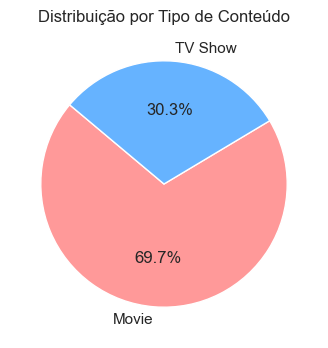

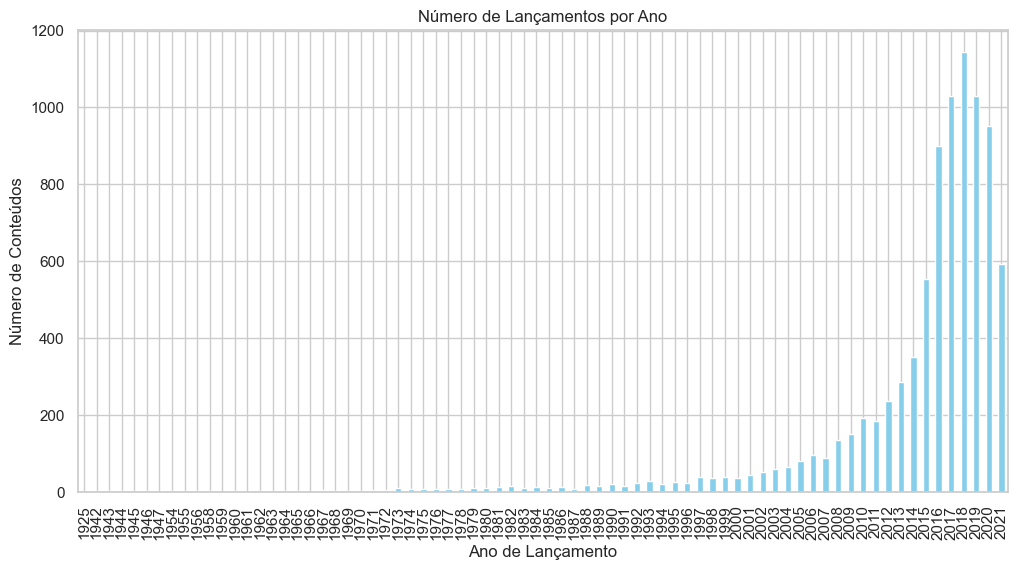

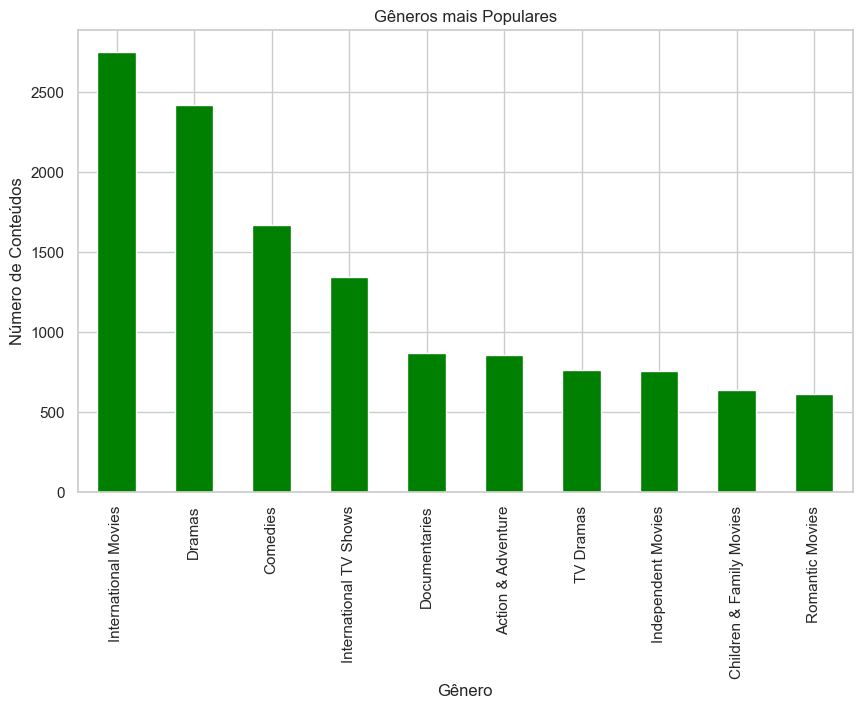

In [18]:
#Visualização de dados

# Conteúdo por tipo
type_count = data['type'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(type_count, labels=type_count.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Distribuição por Tipo de Conteúdo')
plt.show()

# Número de lançamentos por ano
data_by_year = data['release_year'].value_counts().sort_index()
data_by_year.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Número de Lançamentos por Ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Conteúdos')
plt.show()

# Gêneros mais populares
plt.figure(figsize=(10, 6))
all_genres = data['listed_in'].str.split(', ').explode()
all_genres.value_counts().head(10).plot(kind='bar', color='green')
plt.title('Gêneros mais Populares')
plt.xlabel('Gênero')
plt.ylabel('Número de Conteúdos')
plt.show()